In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import scipy.io as sio
import sys
sys.path.insert(0, './modules/')
from modules import data_analysis_tools as dat
from plottingtools import  *
from numpy.linalg import eigvals
from numpy.random import choice
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr
from scipy.stats import gaussian_kde
import mpl_scatter_density
import scipy.stats as stats
plt.rcParams.update({
    "text.usetex": False})
figsDir = '/Users/giuliobondanelli/Dropbox/figures_working/figs_modelling/fig_main/fig_main_panels/'

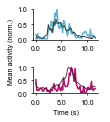

In [4]:
# Fig. 4h - activity examples
f = './data/data_training_relu_thfixed1_vs_psparse_g01_192nets_beta05.pkl'
df = pd.read_pickle(f)
i_par = 3
data_training = df['data'][i_par][0]
input = df.input
signature = df.signature[0]
N = len(signature)

f = './data/trial_avg_activity.pkl'
data = pd.read_pickle(f)
data = data.sort_values(by=['type'],ascending=False)
data = data.reset_index(drop=True)
data = dat.normalize_data_by_peak_of_preferred_trial(data, columns = ['Ca_trial_mean_bR','Ca_trial_mean_wL'])

activity_right = np.stack(data.Ca_trial_mean_bR.values)[None]
activity_left = np.stack(data.Ca_trial_mean_wL.values)[None]
activity = np.concatenate((activity_left, activity_right), axis=0)

R = data_training[0]['R']
dt = 1/5.3

trial_type = 1
fig = figure(figsize=(1.7,2))
ax = fig.add_subplot(111)
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='w', top=False, bottom=False, left=False, right=False)
ax1 = fig.add_subplot(2,1,1)
format_axes(ax1,'1')

i=65
ax1.plot(dt*arange(63), activity[trial_type][i, :], lw=1.5, color='#6ec8da', label='Right')
ax1.plot(dt*arange(63), R[trial_type].T[i, :], lw=0.8, color='#242323')
ax1.set_ylim([0,1])
ax1.set_xticks([0,5,10])
ax1.set_yticks([0,0.5,1])
tight_layout()



ax2 = fig.add_subplot(2,1,2)
format_axes(ax2,'1')

i=135
ax2.plot(dt*arange(63), activity[trial_type][i, :], lw=1.5, color='#e75177', label='Right')
ax2.plot(dt*arange(63), R[trial_type].T[i, :], lw=0.8, color='#242323')
ax2.set_xticks([0,5,10])
ax2.set_yticks([0,0.5,1])
ax2.set_xlabel('Time (s)')
ax2.spines['left'].set_bounds(0,1.)
ax2.set_ylim([0,1.2])
tight_layout()
ax.set_ylabel('Mean activity (norm.)')

plt.savefig(figsDir+'example_RNN_fits.pdf',bbox_inches='tight')

In [5]:
# Setup RNN one network

##
f = './data/data_training_relu_thfixed1_vs_psparse_g01_192nets_beta05.pkl'
df = pd.read_pickle(f)
i_par = 3

data_training = df['data'][i_par][0]
signature = df.signature[0]
N = len(signature)


f = './data/trial_avg_activity.pkl'
data = pd.read_pickle(f)
data = data.sort_values(by=['type'],ascending=False)
data = data.reset_index(drop=True)

# idx_L = data[data.select_idx_MI<0].index
# idx_R = data[data.select_idx_MI>0].index
# idx_c = [idx_L, idx_R]

sel_idx = data.select_idx_MI.values
Pre, Post = np.meshgrid(sel_idx,sel_idx)
PairSelIdx = np.sign(Pre*Post) * np.sqrt(abs(Pre)*abs(Post)) #computes pair selectivity index as in the data
del data
del df


c=0.21458908243172017, p=6.972983914694691e-06


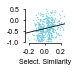

In [63]:
# Fig 4i left - select sim E-I
i_net = 108
s=0.1

figsize=(1.1,1.1)
fig = figure(figsize=figsize)
#ax = fig.add_subplot()
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
format_axes(ax)
format_axes(ax,'1')
W = abs(data_training[i_net]['W_EI'])

weights = dat.get_all_weights_by_type(W, signature)
pair_sel = dat.get_all_weights_by_type(PairSelIdx, signature)

eps = 1e-1
w = array(weights['w_ie'])
p = array(pair_sel['w_ie'])

p = p[w > eps]
w = w[w > eps]
y = log10(np.array(w))

#ax.scatter(np.array(p), y, color='#94a4a8', alpha=1, s=s)
#ax.scatter(np.array(p), y, color='#4D4D4D', alpha=1, s=s)
# xy = np.vstack([np.array(p), y])
# z = gaussian_kde(xy)(xy)
ax.scatter(np.array(p), y, c='#6ec8da', s=s, alpha=1)
#density = ax.scatter_density(np.array(p), y, cmap='hot')
ax.spines['bottom'].set_bounds(-0.2,0.2)
ax.spines['left'].set_bounds(-1,0.5)


X = np.array(p)[:,None]
reg = LinearRegression().fit(X,y)
x_ = linspace(-.3,.3,100)
y_ = reg.intercept_ + reg.coef_ * x_

# corr = pearsonr(np.array(p), y)
corr = spearmanr(np.array(p), np.array(y))
#plot(x_, (y_), lw=1., c='#212d33', label=f'c = {corr[0]:.2f}')
plot(x_, (y_), 'k', lw=0.8, label=f'c = {corr[0]:.2f}')
print(f'c={corr[0]}, p={corr[1]}')
xlabel('Select. Similarity')
yticks([-1,-0.5,0,0.5])
# ylabel('Log (weights)')
# plt.title('E-to-I')
plt.xlim([-0.25,0.25])
ax.set_xticks([-0.2,0,.2])
tight_layout()
plt.savefig(figsDir+'scatter_weights_IE_selectivity.pdf',bbox_inches='tight')

c=-0.031095107706689426, p=0.18594022532062723


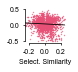

In [64]:
# Fig 4i right: one network sel I-E
fig = figure(figsize=figsize)
ax = fig.add_subplot()
format_axes(ax,'1')
W = abs(data_training[i_net]['W_EI'])

weights = dat.get_all_weights_by_type(W, signature)
pair_sel = dat.get_all_weights_by_type(PairSelIdx, signature)

eps = 10**(-0.5)
w = array(weights['w_ei'])
p = array(pair_sel['w_ei'])
p = p[w > eps]
w = w[w > eps]
y = log10(np.array(w))

#ax.scatter(np.array(p), y, color='#4D4D4D', alpha=1, s=s)
# xy = np.vstack([np.array(p), y])
# z = gaussian_kde(xy)(xy)
ax.scatter(np.array(p), y, c='#e75177', s=s)
ax.spines['bottom'].set_bounds(-0.2,0.2)
ax.spines['left'].set_bounds(-0.5,0.5)

X = np.array(p)[:,None]
reg = LinearRegression().fit(X,y)
x_ = linspace(-.4,.4,100)
y_ = reg.intercept_ + reg.coef_ * x_
# corr = pearsonr(np.array(p), y)
corr = spearmanr(np.array(p), np.array(y))
plot(x_, (y_), 'k',lw=0.8,  label=f'c = {corr[0]:.2f}')
print(f'c={corr[0]}, p={corr[1]}')

xlabel('Select. Similarity')
yticks([-0.5,0,0.5])
# ylabel('Log (weights)')
# plt.title('I-to-E')
plt.xlim([-.25,.25])
ax.set_xticks([-0.2,0,.2])
tight_layout()
plt.savefig(figsDir+'scatter_weights_EI_selectivity.pdf',bbox_inches='tight')

In [34]:
# Setup RNN sel across nets
f = './data/data_training_relu_thfixed1_vs_psparse_g01_192nets_beta05.pkl'
df = pd.read_pickle(f)
n_par = len(df)

results_D_EI = []
results_D_IE = []
results_corr_EI = []
results_corr_IE = []

f = './data/trial_avg_activity.pkl'
data = pd.read_pickle(f)
data = data.sort_values(by=['type'],ascending=False)
data = data.reset_index(drop=True)

idx_L = data[data.select_idx_MI<-0.].index
idx_R = data[data.select_idx_MI>0.].index
idx_c = [idx_L, idx_R]

sel_idx = data.select_idx_MI.values
Pre, Post = np.meshgrid(sel_idx,sel_idx)
PairSelIdx = np.sign(Pre*Post) * np.sqrt(abs(Pre)*abs(Post)) #computes pair selectivity index as in the data

for i_par in range(n_par):
    print(i_par)
    data_training = df['data'][i_par][0]
    signature = df.signature[0]
    N = len(signature)
    n_nets = len(data_training)

    D_EI = np.nan*np.ones(n_nets)
    D_IE = np.nan*np.ones(n_nets)
    corr_EI = np.nan*np.ones(n_nets)
    corr_IE = np.nan*np.ones(n_nets)

    for i_net in range(n_nets):
        W = abs(data_training[i_net]['W_EI'])
        if not hasattr(W,'__len__'):
            continue
        weights = dat.get_all_weights_by_type(W, signature, idx_c)
        pair_sel = dat.get_all_weights_by_type(PairSelIdx, signature, idx_c)

        eps = 1e-5
        w = array(weights['w_ei'])
        p = array(pair_sel['w_ei'])
        p = p[w > eps]
        w = w[w > eps]
        y = log10(np.array(w))
        corr = spearmanr(np.array(p), np.array(y))[0]
        corr_EI[i_net] = corr

        w_in = array(weights['w_ei_in'])
        w_in = w_in[w_in > eps]
        w_out = array(weights['w_ei_out'])
        w_out = w_out[w_out > eps]
        D_EI[i_net] = mean(w_in) - mean(w_out)

        w = array(weights['w_ie'])
        p = array(pair_sel['w_ie'])
        p = p[w > eps]
        w = w[w > eps]
        y = log10(np.array(w))
        corr = spearmanr(np.array(p), np.array(y))[0]
        corr_IE[i_net] = corr

        w_in = array(weights['w_ie_in'])
        w_in = w_in[w_in > eps]
        w_out = array(weights['w_ie_out'])
        w_out = w_out[w_out > eps]
        D_IE[i_net] = mean(w_in) - mean(w_out)

    results_D_IE.append(D_IE)
    results_D_EI.append(D_EI)
    results_corr_IE.append(corr_IE)
    results_corr_EI.append(corr_EI)


del df
del data


0
1
2
3


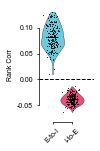

In [75]:
# Fig 4i: sel across networks
i_par = 3
color_points = ['k','k']
color_bodies = ['#6ec9db', '#e85177']

fig = figure(figsize=(1.5,2.2))
ax = fig.add_subplot(111)
format_axes(ax,'2')
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
positions=[1,2]
widths=[1.2,1.2]
data1 = results_corr_IE[i_par]
data2 = results_corr_EI[i_par]
data1 = data1[~isnan(data1)]
data2 = data2[~isnan(data2)]
data = [data1, data2]
parts = ax.violinplot(data, positions=positions, widths=widths, showmedians=True, showextrema=False)
for i in range(len(data)):
    for j in range(len(data[i])):
        plot([positions[i]+random.normal(0,0.15)], [data[i][j]], '.', markeredgewidth=0, markersize=2, alpha=1, color=color_points[i])

i=0
for pc in parts['bodies']:
    pc.set_facecolor(color_bodies[i])
    pc.set_edgecolor('black')
    pc.set_linewidth(0.3)
    pc.set_alpha(1)
    i+=1
parts['cmedians'].set_color('k')
parts['cmedians'].set_linewidth(1)
xticks([1,2],['E-to-I', 'I-to-E'])
plt.xticks(rotation = 45)
xticks([1,2],['E-to-I','I-to-E'])
ax.spines['bottom'].set_bounds(1,2)
ax.spines['left'].set_bounds(-0.05,0.1)
ax.set_ylabel('Rank Corr')
xlim = ax.get_xlim()

ax.set_xlim([xlim[0],xlim[1]+.4])
xlim = ax.get_xlim()

ax.plot(xlim, [0,0], '--', lw=1, color='k')
ylim = ax.get_ylim()
ax.set_ylim([ylim[0]-.01, ylim[1]])
tight_layout()
plt.savefig(figsDir+'violin_selectivity_across_nets.pdf',bbox_inches='tight')

In [47]:
print(stats.ttest_1samp(data[0], 0, axis=0, nan_policy='propagate', alternative='two-sided'))
print(stats.ttest_1samp(data[1], 0, axis=0, nan_policy='propagate', alternative='two-sided'))

TypeError: ttest_1samp() got an unexpected keyword argument 'alternative'

In [36]:
stats.percentileofscore(data[1], 0, kind='rank')

100.0

In [68]:
# Setup perturbations

f = './data/perturbations_relu_thfixed1_vs_psparse_g01_v2_192nets_beta05.pkl'
df = pd.read_pickle(f)


n_nets = int(len(df['data'][0]))
par = df['psparse'].values
n_par = len(par)
n = len(df['data'][0][0]['R2_IE'])

R2_IE = np.nan*np.ones((n_par,n_nets,n))
R2_EI = np.nan*np.ones((n_par,n_nets,n))
dist_orig = np.nan*np.ones((n_par,n_nets,n))
dist_pert_EI = np.nan*np.ones((n_par,n_nets,n))
dist_pert_IE = np.nan*np.ones((n_par,n_nets,n))
acc_pert_EI = np.nan*np.ones((n_par,n_nets,n))
acc_pert_IE = np.nan*np.ones((n_par,n_nets,n))
D_EI = np.nan*np.ones((n_par,n_nets,n))
D_IE = np.nan*np.ones((n_par,n_nets,n))

acceptable_R2 = 0.
central_idx = n//2

for i_par in range(len(df)):
    print(i_par)
    for i_net in range(n_nets):
        data = df['data'][i_par][i_net]
        if isnan(data['R2_IE'][central_idx]) or data['R2_IE'][central_idx] < acceptable_R2:
            continue
        else:
            R2_IE[i_par, i_net, :] = data['R2_IE']
            R2_EI[i_par, i_net, :] = data['R2_EI']
            dist_orig[i_par, i_net, :] = data['dist_orig']
            dist_pert_EI[i_par, i_net, :] = data['dist_pert_EI']
            dist_pert_IE[i_par, i_net, :] = data['dist_pert_IE']
            D_EI[i_par, i_net, :] = data['D_EI']
            D_IE[i_par, i_net, :] = data['D_IE']



0
1
2
3


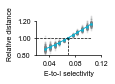

In [80]:
i_par = 3

fig = figure(figsize=(1.7,1.2))
ax = fig.add_subplot(1,1,1)
format_axes(ax)

Z = D_IE[i_par,:,:]
X = Z
condition1 = ~np.isnan(X).any(axis=1)
X = X[condition1, :]
x = mean(X,axis=0)

Z = dist_pert_IE[i_par,:,:]
X = Z/tile(Z[:,central_idx][:,None],(1,n))
X = X[condition1, :]
for i in range(X.shape[0]):
    plot(x, X[i,:], '.', markersize=2, alpha=0.15, color = '#7f8385')
ax.plot(x, median(X, axis=0), '.-', lw=1., markersize=3, color='#0db0d1')
ax.plot([0.02,x[-1]], [1,1], '--', lw=0.7, color='k')
ax.spines['left'].set_bounds(0.8,1.2)
#ax.spines['bottom'].set_bounds(0.04,0.12)
#ax.set_xlabel('E-to-I connect. \nselectivity')
ax.set_xlabel('E-to-I selectivity')
ax.set_ylabel('Relative distance')
plt.xlim(0.02,0.12)
# plt.title('E-to-I')
xticks([0.04,0.08,0.12])
plt.ylim(0.8,1.3)
yticks([0.8,1,1.2])
ylim1 = ax.get_ylim()[0]
ax.plot([x[central_idx],x[central_idx]],[ylim1,median(X, axis=0)[central_idx]], '--', lw=0.7, color='k')
tight_layout()
plt.savefig(figsDir+'perturb_IE.pdf',bbox_inches='tight')

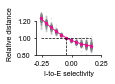

In [81]:
fig = figure(figsize=(1.7,1.2))
ax = fig.add_subplot(1,1,1)
format_axes(ax)

Z = D_EI[i_par,:,:]
X = Z
condition1 = ~np.isnan(X).any(axis=1)
X = X[condition1, :]
x = mean(X,axis=0)

Z = dist_pert_EI[i_par,:,:]
X = Z/tile(Z[:,central_idx][:,None],(1,n))
X = X[condition1, :]
for i in range(X.shape[0]):
    plot(x, X[i,:], '.', markersize=2, alpha=0.15, color = '#7f8385')
ax.plot(x, median(X, axis=0), '.-', lw=1., markersize=5, color='#d61a8b')
ax.plot([x[0],x[-1]], [1,1], '--', lw=0.7, color='k')
ax.spines['left'].set_bounds(0.8,1.2)
#ax.spines['bottom'].set_bounds(-0.25,0.25)
#ax.set_xlabel('I-to-E connect. \nselectivity')
ax.set_xlabel('I-to-E selectivity')
ax.set_ylabel('Relative distance')
# plt.title('I-to-E')
plt.xlim(-0.3,0.2)
xticks([-0.25,0,0.25])
plt.ylim(0.8,1.3)
yticks([0.8,1,1.2])
ylim1 = ax.get_ylim()[0]
ax.plot([x[central_idx],x[central_idx]],[ylim1,median(X, axis=0)[central_idx]], '--', lw=0.7, color='k')
tight_layout()
plt.savefig(figsDir+'perturb_EI.pdf',bbox_inches='tight')